# MNIST classification
This project will work on top of the well known data set MNIST that uses the images of hand-written digits.

In [1]:
# Import necessary libraries for data manipulation, visualization, and machine learning

# Basic libraries for data analysis and manipulation
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import scipy.stats as stats

# Libraries for downloading and extracting data
from pathlib import Path

# Scikit-learn modules for machine learning workflows
import sklearn.datasets
import sklearn.model_selection
import sklearn.preprocessing
import sklearn.compose
import sklearn.pipeline
import sklearn.metrics
import sklearn.impute
import sklearn.base

# Specific ML models
import sklearn.cluster
import sklearn.linear_model
import sklearn.tree
import sklearn.dummy

# Model saving
import joblib

# Data fetching and EDA

## Obtaining the data:
For this, I will be employing the apy from sklearn to fetch the public dataset.

**Getting the data**

In [2]:
mnist = sklearn.datasets.fetch_openml('mnist_784', as_frame=False)

In [3]:
# Understanding the context of the problem
print(dir(mnist),
      mnist.DESCR,
      sep='\n')

['DESCR', 'categories', 'data', 'details', 'feature_names', 'frame', 'target', 'target_names', 'url']
**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the an

**Basic exploration**

In [4]:
# Getting and exploring the data of mnist
X, y = mnist.data, mnist.target

print(X[:5],
      X.shape,
      y[:5],
      y.shape,
      sep='\n\n')

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

(70000, 784)

['5' '0' '4' '1' '9']

(70000,)


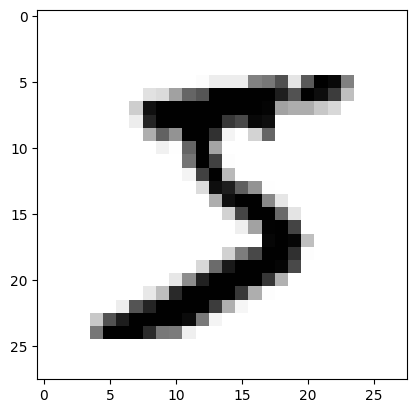

In [5]:
# Basic visualization
plt.imshow(X[0, :].reshape(28, 28), cmap='binary')
plt.show()

## Train-test split

In [6]:
# According to the description, the first 60.000 registers are training samples and the last 10.000 is the test set
x_train, x_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

print(x_train.shape,
      x_test.shape,
      y_train.shape,
      y_test.shape,
      sep='\n')

(60000, 784)
(10000, 784)
(60000,)
(10000,)


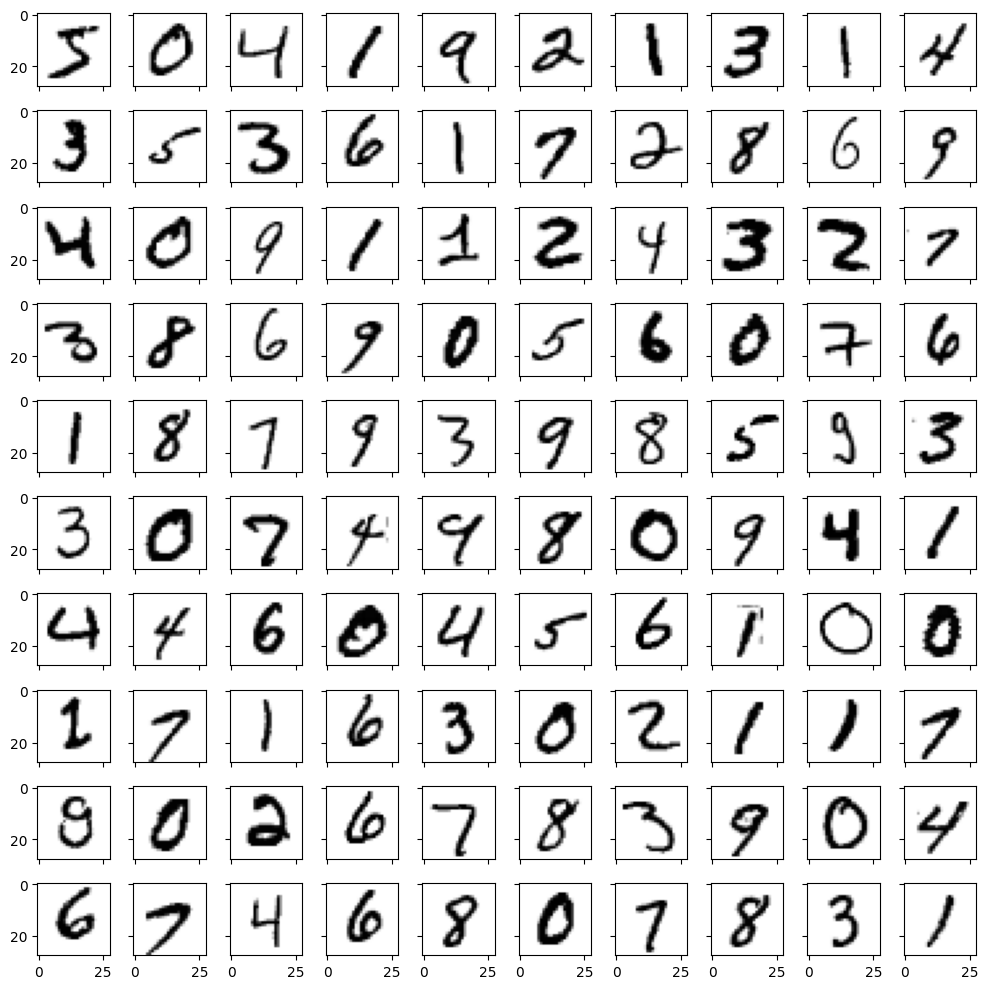

In [7]:
# Getting a visualization of some of the registers in the dataset
nrows = 10
ncolumns = 10
fig, ax = plt.subplots(nrows=nrows, ncols=ncolumns, figsize=(ncolumns, nrows), sharex=True, sharey=True)

for i in range(0, nrows * ncolumns):
    # Plotting per each of the canvas
    axs = ax[i // nrows, i % ncolumns]
    axs.imshow(x_train[i,:].reshape(28, 28), cmap='binary')

plt.tight_layout()
plt.show()

As the data has been already treated, centred, and normalized, there would not be a stage for preprocessing. In addition, as each of the features represent a pixel of a 28x28 image. There would not be a statistical exploration to understand the distributions and main descriptive properties of the data. 

# Training a model for a single class
For this part of the exercise I will be creating a model for forecasting a single class. In this case, I would try to create a model able to predict when a specific image is a 5.

**Comparing models for imbalanced data sets**

In [8]:
# Modification of the targets so the individual model
y_train_5 = (y_train.copy() == '5')
y_test_5 = (y_test.copy() == '5')

print(pd.Series(y_train_5).value_counts(),
      pd.Series(y_test_5).value_counts(),
      sep='\n')

False    54579
True      5421
Name: count, dtype: int64
False    9108
True      892
Name: count, dtype: int64


## Model with a standard linear model fit via stochastic gradient descent

In [9]:
# Training a basic linear model with stochastic gradient descent. It uses a base linear SVM algorithm.
sgd_model = sklearn.linear_model.SGDClassifier(random_state=42)
sgd_model = sgd_model.fit(x_train, y_train_5)

sklearn.metrics.accuracy_score(y_train_5, sgd_model.predict(x_train))

0.9522666666666667

In [10]:
# Evaluating the performance via cross validation:
cv_sgd = sklearn.model_selection.cross_val_score(estimator=sgd_model, X=x_train, y=y_train_5, cv=3, scoring='accuracy')
pd.Series(cv_sgd).describe()

count    3.000000
mean     0.957033
std      0.005788
min      0.950350
25%      0.955350
50%      0.960350
75%      0.960375
max      0.960400
dtype: float64

It seems that the model performs well. Nevertheless, this could be due to the imbalances in the classes. Hence, I would compare its performance against a model that only predicts the most common class.

## Comparison against a dummy predictor that always forests the most common class

In [ ]:
# Training a basic model with most frequent strategy
dummy_model = sklearn.dummy.DummyClassifier(strategy='most_frequent')
dummy_model = dummy_model.fit(x_train, y_train_5)

sklearn.metrics.accuracy_score(y_train_5, dummy_model.predict(x_train))

0.90965

In [14]:
# Performing a cross validation comparison
cv_dummy = sklearn.model_selection.cross_val_score(estimator=dummy_model, X=x_train, y=y_train_5, cv = 3, scoring='accuracy')
pd.Series(cv_dummy).describe()

count    3.00000
mean     0.90965
std      0.00000
min      0.90965
25%      0.90965
50%      0.90965
75%      0.90965
max      0.90965
dtype: float64

As we can see, the cross validation of the dummy classifier has a good performance as well. Hence, it seems that the data set could have an imbalance in the different classes, which could be the main reason why both models are having a high accuracy. Which could uncover the reality that such metric is not the best one for comparing a determining the performance of these models under such circumstances.

## Exploring the trade-offs in classification
This subanalysis will focus primarly on the main basic model, the sgd linear model.

For starters, I will explore the results returned in terms of the confusion matrix.

In [24]:
# Creating a confusion matric
class_labels = sgd_model.classes_

cmatrix = sklearn.metrics.confusion_matrix(y_train_5, sgd_model.predict(x_train))
pd.DataFrame(cmatrix, index=class_labels, columns=class_labels)
# From it we can identify that there is a strong imbalance in the data set. There is ahigh presence of false positives (a large number of true predicted labels when they were in reality false).

,False,True
False,52316,2263
True,601,4820


In [38]:
# Evaluating other important metrics for evidencing the performance of the model
print(f'Accuracy: {sklearn.metrics.accuracy_score(y_train_5, sgd_model.predict(x_train))}',
      f'Precision: {sklearn.metrics.precision_score(y_train_5, sgd_model.predict(x_train))}',
      f'Recall: {sklearn.metrics.recall_score(y_train_5, sgd_model.predict(x_train))}',
      f'Specificity: {cmatrix[1, 1] / sum(cmatrix[1, :])}',
      f'False positive discovery score: {cmatrix[1, 0] / sum(cmatrix[1, :])}',
      sep='\n')

Accuracy: 0.9522666666666667
Precision: 0.6805026118876183
Recall: 0.8891348459693783
Specificity: 0.8891348459693783
False positive discovery score: 0.11086515403062165


From this we can identify that indeed the model has dificulties predicting the smallest class. This is attributed to a high accuracy and recall, but a much lower precision.

Secondly, I will explore the trade-off between **precision and recall**. This could allow us to explore the possibility of tunning the threshold of the model. Ultimately improving the balance of it, but by sacrificing one of the attributes (precision or recall).

In [ ]:
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(y_true=y_train_5, y_score=sgd_model.decision_function(x_train))

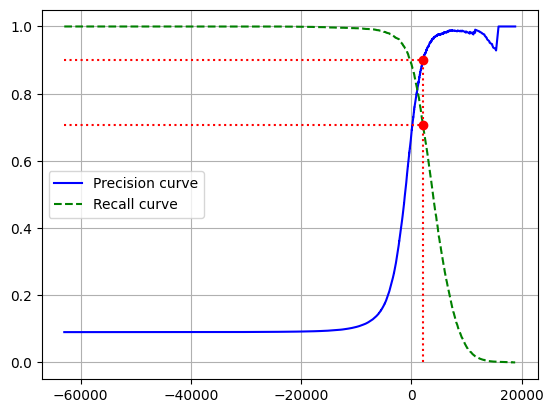

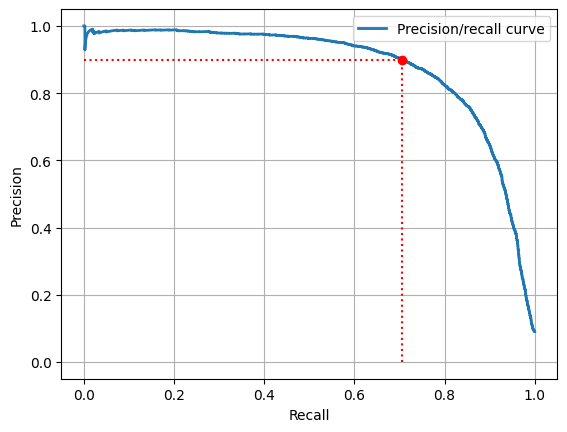

Threshold for 90% precision: 2123.5620469950154


In [ ]:
recall_90_precision = recall[np.argmax(precision >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precision >= 0.90)]

# Precision and recall parallel curves
plt.plot(thresholds, precision[:-1], 'b-', label= 'Precision curve')
plt.plot(thresholds, recall[:-1], 'g--', label = 'Recall curve')
# plt.vlines(0, 0, 1, 'r')
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")                 # Not shown
plt.plot([np.min(thresholds), threshold_90_precision], [0.9, 0.9], "r:")                                # Not shown
plt.plot([np.min(thresholds), threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")# Not shown
plt.plot([threshold_90_precision], [0.9], "ro")                                             # Not shown
plt.plot([threshold_90_precision], [recall_90_precision], "ro")
plt.grid()
plt.legend()
plt.show()

# Precision and recall curve
plt.plot(recall, precision, linewidth=2, label='Precision/recall curve')
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
plt.grid()
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Printing the threshold that allows us to get 90% of precision
print('Threshold for 90% precision: {}'.format(threshold_90_precision))

From the plots we can conclude that, if the threshold could be optimized, we would be able to balance the precision and recall up to a point that both scores are near 80%. Nevertheless, as a classification task, it is most likely that we would prioritize one of the measurements and would like to sacrifice the other.

Thirdly, a closely related idea that could allow us to understand the performance of the model is the **receiver operating characteristic (ROC) curve**. With it, we can distinguish the trade-off between recall and the false positive descovery rate.

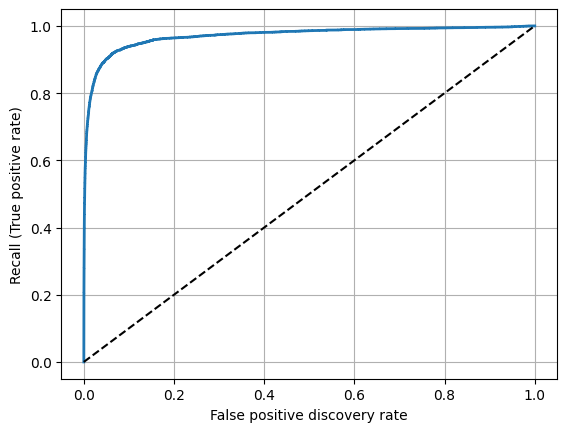

0.9709618248430906

In [79]:
# Getting the ROC curve.
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_train_5, sgd_model.decision_function(x_train))
plt.plot(fpr, tpr, linewidth=2, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive discovery rate')
plt.ylabel('Recall (True positive rate)')
plt.grid()
plt.show()

sklearn.metrics.roc_auc_score(y_train_5, sgd_model.decision_function(x_train))

From the ROC curve, we can identify two main findings:
1. By modifying the threshold we can see that we can improve the recall of the model, but it would come at the price of increasing also the false positive discovery rate; hence, reducing the specificity of the model. As a result, this translates into the evaluation of this trade-off when modifying the base 0 decision threshold form the SGD model.
2. Despite the curve demonstrating a stable model for the identification. Because it still has some area above it, we can potentially suggest that there could be a better alternative (in terms of models) to be explored.

## Alternative model: Random Forest

In [81]:
# Fitting a random forest and evaluating its performance
rf_model = sklearn.ensemble.RandomForestClassifier(random_state=42)
rf_model = rf_model.fit(x_train, y_train_5)

# Evaluating the base accuracy
sklearn.metrics.accuracy_score(y_train_5, rf_model.predict(x_train))

1.0

In [96]:
# Confusion matrix
sklearn.metrics.confusion_matrix(y_train_5, rf_model.predict(x_train))

array([[54579,     0],
       [    0,  5421]])

In [82]:
# Evaluating its performance in cross validation
rf_results = sklearn.model_selection.cross_val_score(estimator=rf_model, X=x_train, y=y_train_5, cv=3, scoring='accuracy')
pd.Series(rf_results).describe()

count    3.000000
mean     0.987167
std      0.001458
min      0.986300
25%      0.986325
50%      0.986350
75%      0.987600
max      0.988850
dtype: float64

In [86]:
rf_predictions = sklearn.model_selection.cross_val_predict(rf_model, x_train, y_train_5, cv=3, method='predict_proba')
rf_predictions[:5]

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       [1.  , 0.  ],
       [0.99, 0.01]])

**Estimating both curves precision-recall and ROC**

In [ ]:
# Getting the simulated out-of-sample predictions
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(y_train_5, rf_predictions[:, 1])

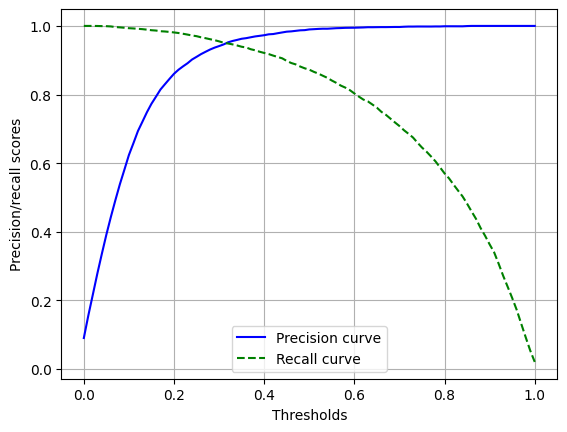

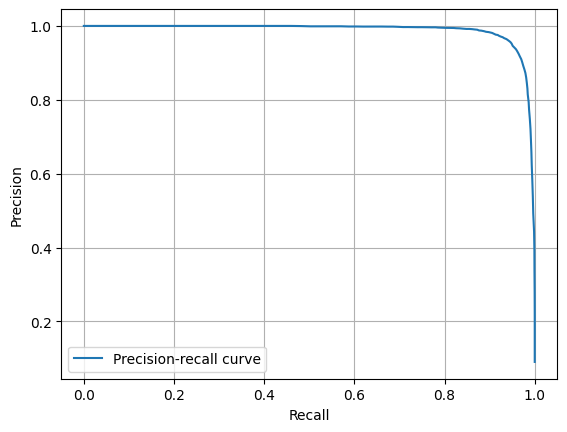

In [95]:
# Contrasting the precision and recall trade-off
# Precision-recall blades
plt.plot(thresholds, precision[:-1], 'b-', label='Precision curve')
plt.plot(thresholds, recall[:-1], 'g--', label='Recall curve')
plt.legend()
plt.xlabel('Thresholds')
plt.ylabel('Precision/recall scores')
plt.grid()
plt.show()

# Precision-recall trade-off
plt.plot(recall, precision, label = 'Precision-recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()

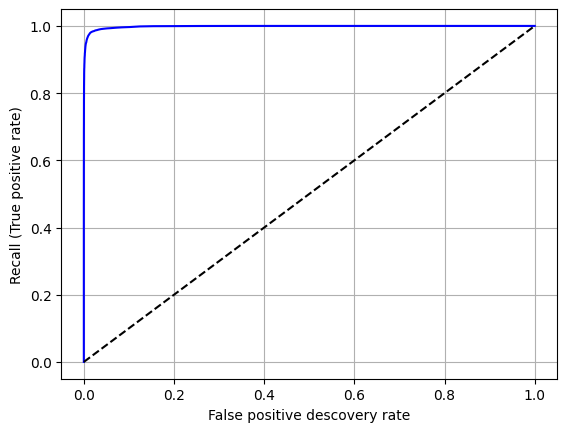

0.9983436731328145

In [102]:
# Estimating the ROC curve
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_train_5, rf_predictions[:, 1])

plt.plot(fpr, tpr, 'b-', label = 'ROC curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive descovery rate')
plt.ylabel('Recall (True positive rate)')
plt.grid()
plt.show()

# Estimating the AUC
sklearn.metrics.roc_auc_score(y_true=y_train_5, y_score=rf_predictions[:, 1])

From this overview, we can evidence that the random forest seems to be a much better classifier for this task compared to the SGD linear model classifier counterpart. This finding is supported by all, accuracy, precision-recall trade-off, and ROC (recall-false positive descovery rate trade-off).